# FEMTO-ST RUL — Methodology, Detector & Two-Stage Evaluation

This notebook documents the *reasoning* behind the project, end to end:

1. what the raw data looks like and how a snapshot becomes health indicators;
2. the RUL **labelling** decision (linear / capped) — the dominant lever;
3. the XGBoost vs LSTM comparison and its seed variance;
4. an **event-driven onset detector** (slope-based) and its validation;
5. an investigated **negative result** (no reliable early-warning "yellow" signal);
6. the **two-stage system** (detector → post-alarm RUL) evaluated with
   leave-one-bearing-out, including the honest caveat that the metric gain does
   not mean the models track the terminal collapse — a data-observability limit.

Models are defined in `src/`; this notebook is the narrative and the experiments.


In [1]:
%load_ext autoreload
%autoreload 2

## 1. What one bearing looks like

Each bearing folder holds thousands of `acc_*.csv` snapshots. Each snapshot is
2560 samples (0.1 s at 25.6 kHz) of horizontal + vertical acceleration, recorded
every 10 s. So a bearing's life is a *time series of snapshots*.

snapshots in this bearing: 2803
one snapshot shape: (2560, 2)


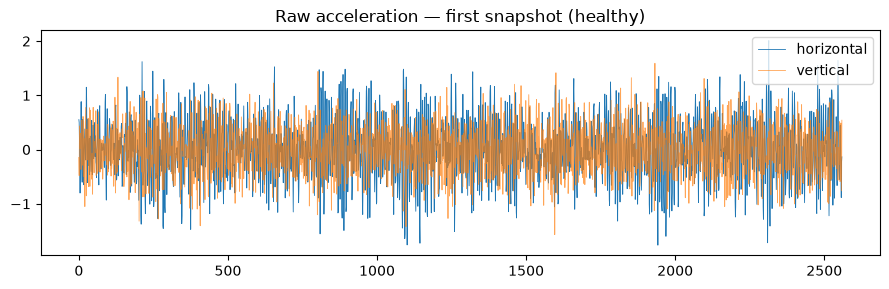

In [2]:
import sys; sys.path.append("..")
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.data_loading import load_snapshot, n_snapshots, _acc_files

bearing = config.DATA_ROOT / "Learning_set" / "Bearing1_1"   # adjust to your layout
print("snapshots in this bearing:", n_snapshots(bearing))

snap = load_snapshot(_acc_files(bearing)[0])
print("one snapshot shape:", snap.shape)   # (2560, 2)

plt.figure(figsize=(9,3))
plt.plot(snap[:,0], lw=0.6, label="horizontal")
plt.plot(snap[:,1], lw=0.6, label="vertical", alpha=0.7)
plt.title("Raw acceleration — first snapshot (healthy)"); plt.legend(); plt.tight_layout()

## 2. Health indicators over life

RMS is energy; kurtosis is spikiness (rises early when a spall starts hitting a
rolling element). Watch how they stay flat for most of the bearing's life, then
climb sharply near failure — that flat region is *why* linear RUL is misleading.

(2803, 35)


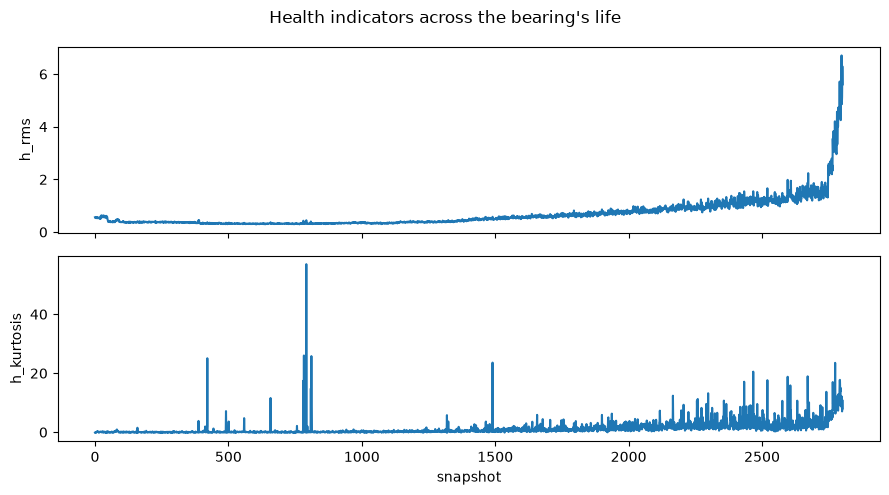

In [3]:
from src.features import build_feature_frame
df = build_feature_frame(bearing)     # one row per snapshot (cached in results/)
print(df.shape)

fig, ax = plt.subplots(2,1, figsize=(9,5), sharex=True)
ax[0].plot(df["h_rms"]);      ax[0].set_ylabel("h_rms")
ax[1].plot(df["h_kurtosis"]); ax[1].set_ylabel("h_kurtosis"); ax[1].set_xlabel("snapshot")
fig.suptitle("Health indicators across the bearing's life"); fig.tight_layout()

## 3. The labelling decision — linear vs piecewise

**Linear RUL** = `total_life − t`: a straight line. It claims the bearing is
already dying at t=0. During the long flat health region above, this forces the
model to predict a specific countdown from a signal that carries no degradation
information yet — it learns position-in-file, not physics.

**Piecewise-linear RUL**: flat plateau until a detected degradation onset (First
Prediction Time), then a linear ramp to zero. This says RUL only becomes a
meaningful countdown once damage is detectable.

Where the knee sits is an *event-detection* problem on the health trajectory.
The detector below is a transparent baseline (RMS leaving a healthy band); a
proper event-driven labeller is the obvious upgrade.

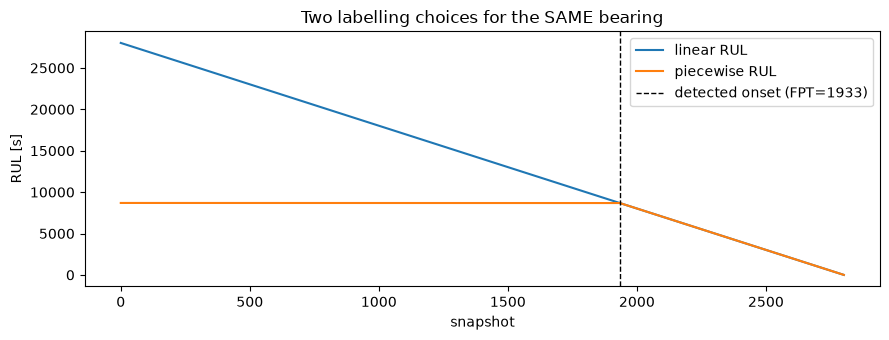

In [4]:
from src.labeling import linear_rul, piecewise_rul, detect_fpt

n = len(df)
fpt = detect_fpt(df["h_rms"].to_numpy())
lin = linear_rul(n)
pw  = piecewise_rul(n, fpt)

plt.figure(figsize=(9,3.5))
plt.plot(lin, label="linear RUL")
plt.plot(pw,  label="piecewise RUL")
plt.axvline(fpt, color="k", ls="--", lw=1, label=f"detected onset (FPT={fpt})")
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend()
plt.title("Two labelling choices for the SAME bearing"); plt.tight_layout()

Text(0.5, 1.0, 'Bearing1_3 — XGBoost')

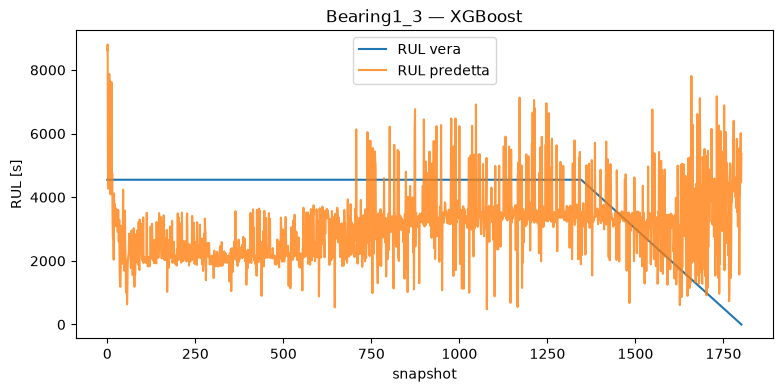

In [5]:
import numpy as np, matplotlib.pyplot as plt
from xgboost import XGBRegressor
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler

train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1","Bearing3_2"]
train_data = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, cache=False) for n in train_names}
scalers, cols = fit_scalers(train_data)

Xtr = np.concatenate([apply_scaler(n, df, scalers, cols) for n,(df,_) in train_data.items()])
ytr = np.concatenate([t for _,t in train_data.values()])
model = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.03,
                     subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42).fit(Xtr, ytr)

df, ytrue = prepare_bearing(config.DATA_ROOT/"Test_set"/"Bearing1_3", cache=False)
ypred = model.predict(apply_scaler("Bearing1_3", df, scalers, cols))

plt.figure(figsize=(9,4))
plt.plot(ytrue, label="RUL vera")
plt.plot(ypred, label="RUL predetta", alpha=0.8)
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend(); plt.title("Bearing1_3 — XGBoost")

## 4. Leakage checklist (before any modelling)

- [ ] split is **by bearing**, never by random snapshot
- [ ] scaler fit on **training bearings only**, applied per operating condition
- [ ] validation bearing (for early stopping) is held out from *training*, not from test
- [ ] sequence windows never cross a bearing boundary

If all four hold, the numbers in the README table mean something. If any fails,
the model looks great and generalises to nothing.

Text(0.5, 1.0, "Target 'capped' — cap fisso a 5000s")

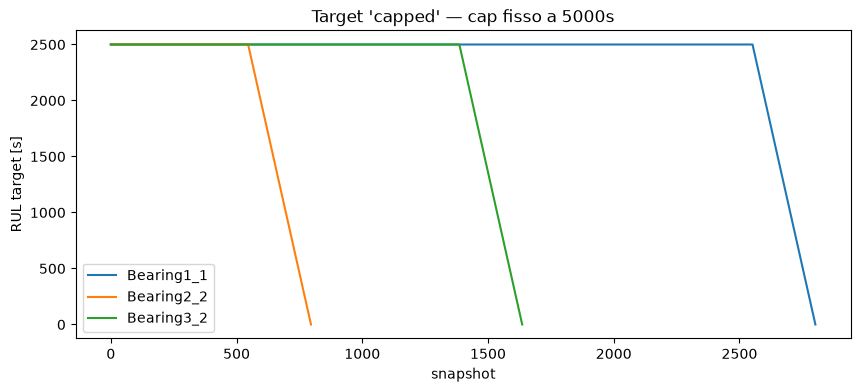

In [6]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame
from src.labeling import make_targets

names = ["Bearing1_1","Bearing2_2","Bearing3_2"]  # i tre casi più diversi
plt.figure(figsize=(10,4))
for n in names:
    df = build_feature_frame(config.DATA_ROOT/"Learning_set"/n)
    t = make_targets(df, mode="capped")
    plt.plot(t, label=n)
plt.xlabel("snapshot"); plt.ylabel("RUL target [s]"); plt.legend()
plt.title("Target 'capped' — cap fisso a 5000s")

epoch   1 | train       0.04 | val       0.00
epoch   2 | train       0.00 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.00
epoch   7 | train       0.00 | val       0.00
epoch   8 | train       0.00 | val       0.00
epoch   9 | train       0.00 | val       0.00
epoch  10 | train       0.00 | val       0.00
epoch  11 | train       0.00 | val       0.00
epoch  12 | train       0.00 | val       0.00
epoch  13 | train       0.00 | val       0.00
early stopping at epoch 13


Text(0.5, 1.0, 'Bearing1_3 — LSTM (capped)')

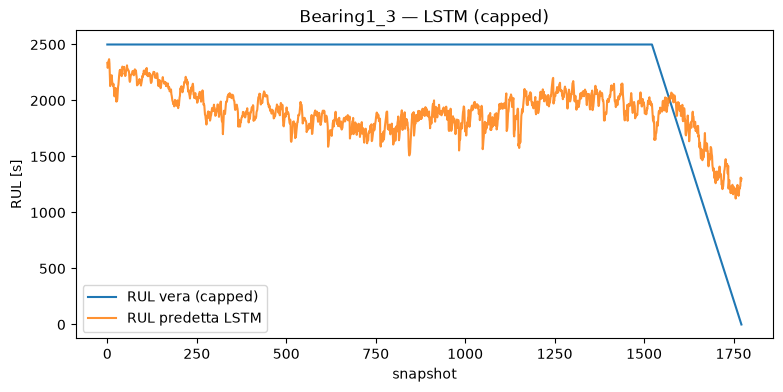

In [7]:
import numpy as np, matplotlib.pyplot as plt, torch
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from torch.utils.data import DataLoader

RUL_SCALE = 1.0/9000.0
WINDOW = 30
MODE = "capped"
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]
val_name = "Bearing3_2"
tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in train_names}
scalers, cols = fit_scalers(tr)
def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
train_ds = SequenceDataset(pairs(tr), window=WINDOW)
vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, label_mode=MODE, cache=False)}
val_ds = SequenceDataset(pairs(vd), window=WINDOW)
model = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
out = train_model(model, DataLoader(train_ds,128,shuffle=True), DataLoader(val_ds,128), epochs=100)
model = out["model"]; device = get_device(); model.eval()

df, ytrue = prepare_bearing(config.DATA_ROOT/"Test_set"/"Bearing1_3", label_mode=MODE, cache=False)
X,_ = make_sequences(apply_scaler("Bearing1_3",df,scalers,cols), ytrue*RUL_SCALE, window=WINDOW)
with torch.no_grad():
    pred = model(torch.from_numpy(X).to(device)).cpu().numpy()/RUL_SCALE
plt.figure(figsize=(9,4))
plt.plot(ytrue[WINDOW-1:], label="RUL vera (capped)")
plt.plot(pred, label="RUL predetta LSTM", alpha=0.85)
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend(); plt.title("Bearing1_3 — LSTM (capped)")

epoch   1 | train       0.05 | val       0.00
epoch   2 | train       0.00 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.00
epoch   7 | train       0.00 | val       0.00
epoch   8 | train       0.00 | val       0.00
epoch   9 | train       0.00 | val       0.00
epoch  10 | train       0.00 | val       0.00
epoch  11 | train       0.00 | val       0.00
epoch  12 | train       0.00 | val       0.00
epoch  13 | train       0.00 | val       0.00
epoch  14 | train       0.00 | val       0.00
epoch  15 | train       0.00 | val       0.00
epoch  16 | train       0.00 | val       0.00
epoch  17 | train       0.00 | val       0.00
epoch  18 | train       0.00 | val       0.00
early stopping at epoch 18
           RMSE      MAE     PHM(traiettoria)
XGBoost       540      435   0.561
LSTM          890      823   0.325


Text(0.5, 1.0, 'Bearing1_3 — confronto')

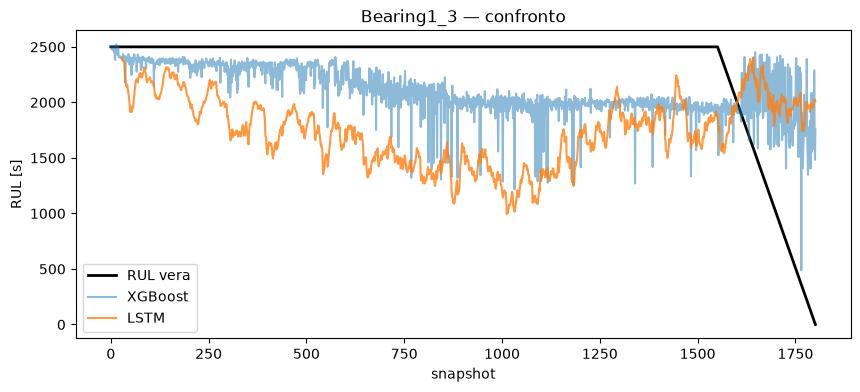

In [8]:
import numpy as np, matplotlib.pyplot as plt, torch
from xgboost import XGBRegressor
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from src.evaluate import rmse, mae, phm_score
from torch.utils.data import DataLoader

RUL_SCALE, WINDOW, MODE = 1.0/9000.0, 30, "capped"
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]
val_name, test_name = "Bearing3_2", "Bearing1_3"

tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in train_names}
scalers, cols = fit_scalers(tr)

# --- XGBoost ---
Xtr = np.concatenate([apply_scaler(n,df,scalers,cols) for n,(df,_) in tr.items()])
ytr = np.concatenate([t for _,t in tr.values()])
xgb = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.03,
                   subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42).fit(Xtr, ytr)

# --- LSTM ---
def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, label_mode=MODE, cache=False)}
lstm = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
out = train_model(lstm, DataLoader(SequenceDataset(pairs(tr),WINDOW),128,shuffle=True),
                  DataLoader(SequenceDataset(pairs(vd),WINDOW),128), epochs=100)
lstm = out["model"]; dev = get_device(); lstm.eval()

# --- predizioni sul test ---
df, ytrue = prepare_bearing(config.DATA_ROOT/"Test_set"/test_name, label_mode=MODE, cache=False)
Xs = apply_scaler(test_name, df, scalers, cols)
xgb_pred = xgb.predict(Xs)
Xseq,_ = make_sequences(Xs, ytrue*RUL_SCALE, window=WINDOW)
with torch.no_grad():
    lstm_pred = lstm(torch.from_numpy(Xseq).to(dev)).cpu().numpy()/RUL_SCALE
yt_aligned = ytrue[WINDOW-1:]

print("           RMSE      MAE     PHM(traiettoria)")
print(f"XGBoost   {rmse(ytrue,xgb_pred):7.0f}  {mae(ytrue,xgb_pred):7.0f}   {phm_score(ytrue,xgb_pred):.3f}")
print(f"LSTM      {rmse(yt_aligned,lstm_pred):7.0f}  {mae(yt_aligned,lstm_pred):7.0f}   {phm_score(yt_aligned,lstm_pred):.3f}")

plt.figure(figsize=(10,4))
plt.plot(ytrue, "k", label="RUL vera", lw=2)
plt.plot(xgb_pred, label="XGBoost", alpha=0.5)
plt.plot(range(WINDOW-1, WINDOW-1+len(lstm_pred)), lstm_pred, label="LSTM", alpha=0.8)
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend(); plt.title(f"{test_name} — confronto")

## 5. Variance across random seeds

The LSTM is high-variance with only five training bearings, so single-run numbers mislead. We report mean ± std over 5 seeds — this is what the README table uses.

In [9]:
import numpy as np, torch
from xgboost import XGBRegressor
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from src.evaluate import rmse
from torch.utils.data import DataLoader

RUL_SCALE, WINDOW, MODE = 1.0/9000.0, 30, "capped"
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]
val_name = "Bearing3_2"; test_names = ["Bearing1_3","Bearing2_3","Bearing3_3"]

tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in train_names}
scalers, cols = fit_scalers(tr)
vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, label_mode=MODE, cache=False)}
test = {n: prepare_bearing(config.DATA_ROOT/"Test_set"/n, label_mode=MODE, cache=False) for n in test_names}
def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]

# XGBoost (deterministico)
Xtr = np.concatenate([apply_scaler(n,df,scalers,cols) for n,(df,_) in tr.items()])
ytr = np.concatenate([t for _,t in tr.values()])
xgb = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.03,
                   subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42).fit(Xtr, ytr)
xgb_rmse = {}
for n,(df,ytrue) in test.items():
    xgb_rmse[n] = rmse(ytrue, xgb.predict(apply_scaler(n,df,scalers,cols)))

# LSTM x 5 seed
dev = get_device()
lstm_rmse = {n: [] for n in test_names}
for seed in range(5):
    torch.manual_seed(seed); np.random.seed(seed)
    m = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
    out = train_model(m, DataLoader(SequenceDataset(pairs(tr),WINDOW),128,shuffle=True),
                      DataLoader(SequenceDataset(pairs(vd),WINDOW),128), epochs=100)
    m = out["model"]; m.eval()
    for n,(df,ytrue) in test.items():
        Xseq,_ = make_sequences(apply_scaler(n,df,scalers,cols), ytrue*RUL_SCALE, window=WINDOW)
        with torch.no_grad():
            lp = m(torch.from_numpy(Xseq).to(dev)).cpu().numpy()/RUL_SCALE
        lstm_rmse[n].append(rmse(ytrue[WINDOW-1:], lp))
    print(f"seed {seed} done")

print(f"\n{'Bearing':<12}{'XGB RMSE':>10}{'LSTM RMSE (media±std, n=5)':>30}")
for n in test_names:
    arr = np.array(lstm_rmse[n])
    print(f"{n:<12}{xgb_rmse[n]:>10.0f}      {arr.mean():>6.0f} ± {arr.std():>4.0f}")

epoch   1 | train       0.03 | val       0.00
epoch   2 | train       0.00 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.00
epoch   7 | train       0.00 | val       0.00
epoch   8 | train       0.00 | val       0.00
epoch   9 | train       0.00 | val       0.00
epoch  10 | train       0.00 | val       0.00
epoch  11 | train       0.00 | val       0.00
epoch  12 | train       0.00 | val       0.00
epoch  13 | train       0.00 | val       0.00
epoch  14 | train       0.00 | val       0.00
epoch  15 | train       0.00 | val       0.00
epoch  16 | train       0.00 | val       0.00
epoch  17 | train       0.00 | val       0.00
epoch  18 | train       0.00 | val       0.00
epoch  19 | train       0.00 | val       0.00
epoch  20 | train       0.00 | val       0.00
epoch  21 | train       0.00 | val       0.00
epoch  22 | train       0.00 | val

## 6. An event-driven onset detector

The threshold detector above was inconsistent (First Prediction Time ranged 32–99% of life). Here we build a robust alternative: detect the *terminal acceleration* of degradation from the slope of the smoothed RMS, after discarding the start-up transient. First we look at the transient and the slope signal, then the detector's consistency across bearings, its generalisation, and its documented failure mode (Bearing2_3).

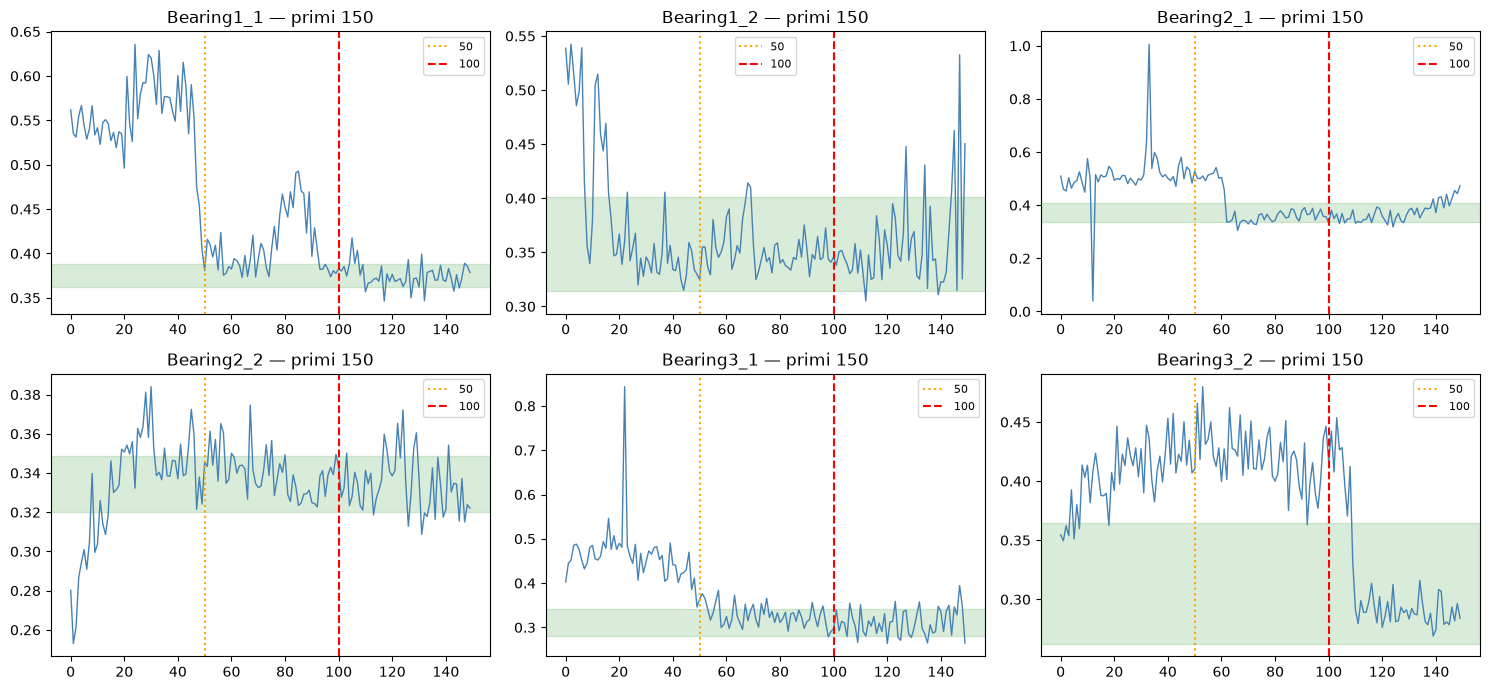

In [10]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame

names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1","Bearing3_2"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, n in zip(axes.ravel(), names):
    rms = build_feature_frame(config.DATA_ROOT/"Learning_set"/n)["h_rms"].to_numpy()
    z = rms[:150]
    ax.plot(z, color="steelblue", lw=1)
    ax.axvline(50, color="orange", ls=":", label="50")
    ax.axvline(100, color="red", ls="--", label="100")
    # banda di riferimento: media±std calcolata sugli snapshot 100-150 (presunto "sano stabile")
    stable = rms[100:150]
    ax.axhspan(stable.mean()-stable.std(), stable.mean()+stable.std(), color="green", alpha=0.15)
    ax.set_title(f"{n} — primi 150"); ax.legend(fontsize=8)
plt.tight_layout()


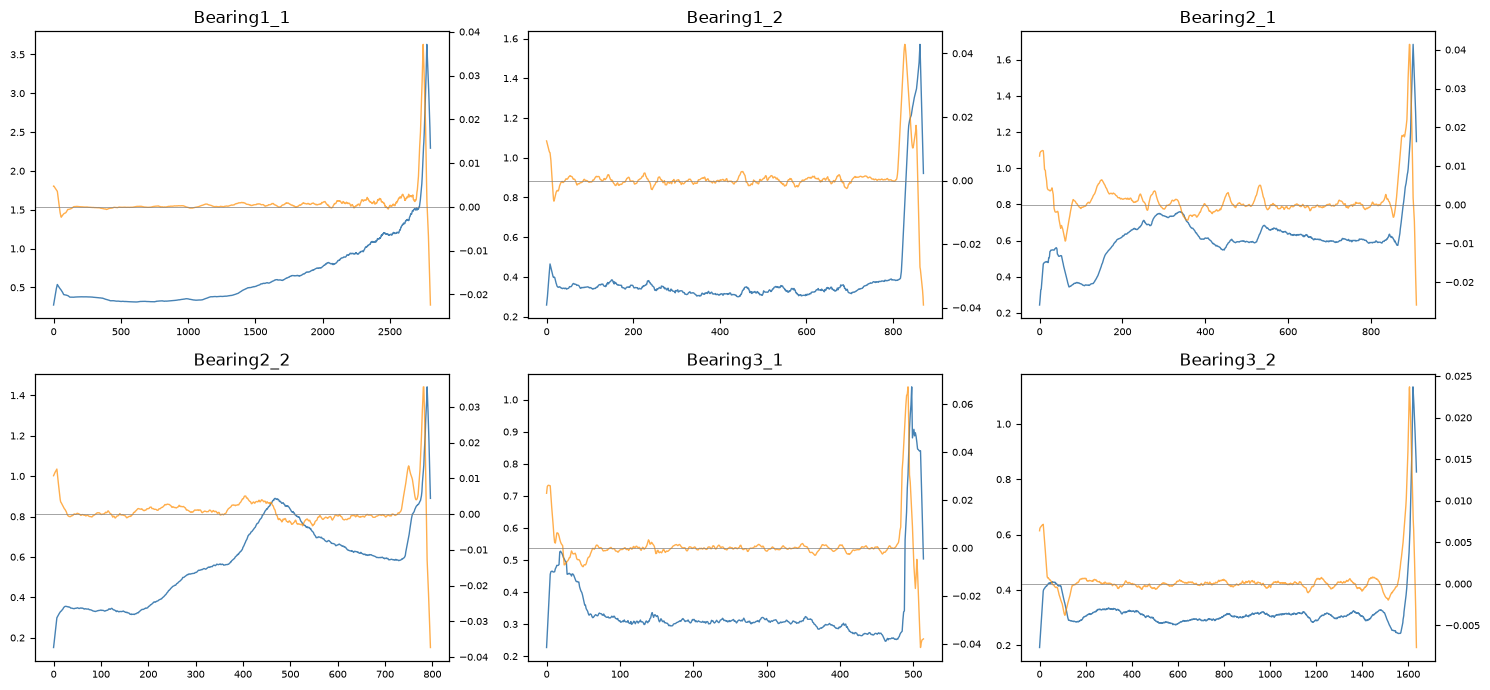

In [11]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame

names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1","Bearing3_2"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, n in zip(axes.ravel(), names):
    rms = build_feature_frame(config.DATA_ROOT/"Learning_set"/n)["h_rms"].to_numpy()
    # smussatura forte per togliere il rumore ad alta frequenza
    win = max(5, len(rms)//50)
    sm = np.convolve(rms, np.ones(win)/win, mode="same")
    slope = np.gradient(sm)                     # pendenza del RMS smussato
    slope_sm = np.convolve(slope, np.ones(win)/win, mode="same")  # pendenza smussata

    ax2 = ax.twinx()
    ax.plot(sm, color="steelblue", lw=1, label="RMS smussato")
    ax2.plot(slope_sm, color="darkorange", lw=1, alpha=0.7, label="pendenza")
    ax2.axhline(0, color="gray", lw=0.5)
    ax.set_title(n)
    ax.tick_params(labelsize=7); ax2.tick_params(labelsize=7)
plt.tight_layout()

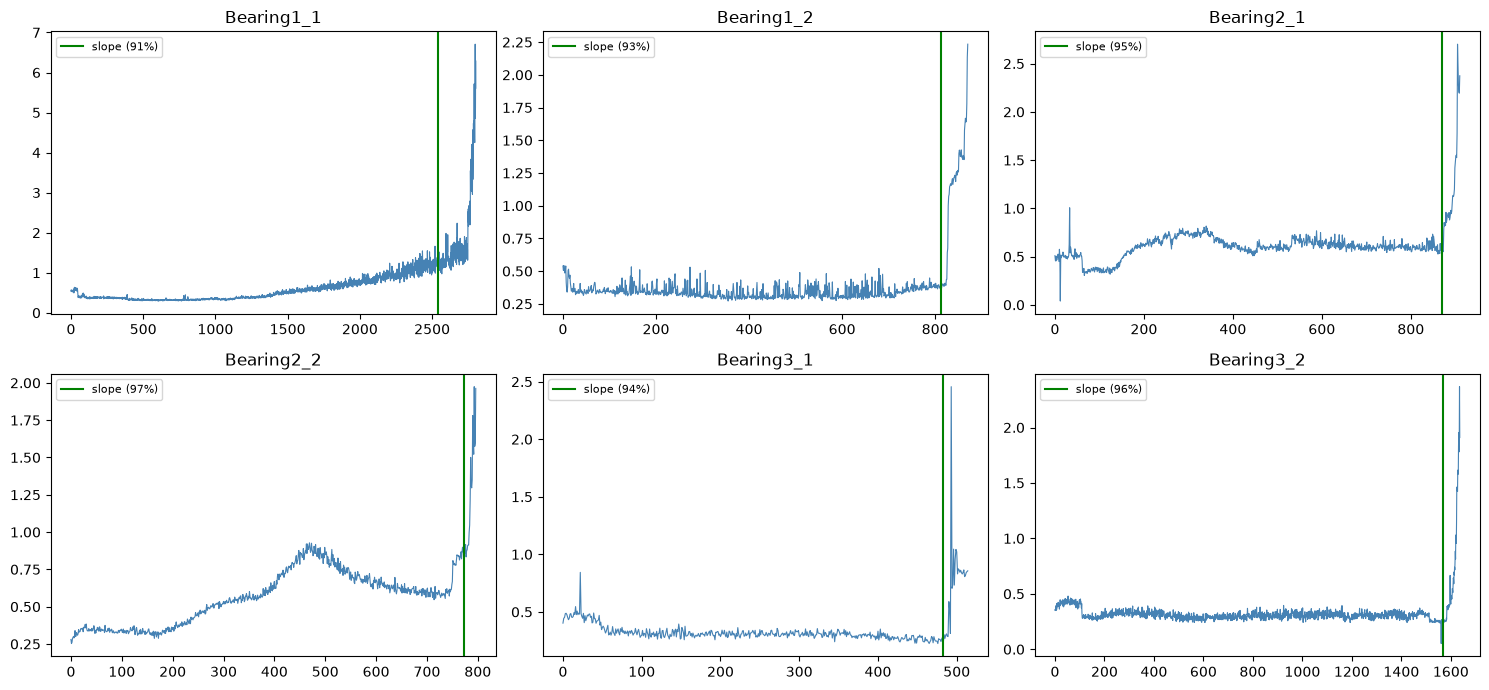

In [12]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame
from src.labeling import detect_fpt_slope

names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1","Bearing3_2"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, n in zip(axes.ravel(), names):
    rms = build_feature_frame(config.DATA_ROOT/"Learning_set"/n)["h_rms"].to_numpy()
    fpt = detect_fpt_slope(rms)
    ax.plot(rms, color="steelblue", lw=0.8)
    ax.axvline(fpt, color="green", label=f"slope ({100*fpt/len(rms):.0f}%)")
    ax.set_title(n); ax.legend(fontsize=8)
plt.tight_layout()

In [13]:
import numpy as np
from src import config
from src.features import build_feature_frame
from src.labeling import detect_fpt_slope

print(f"{'bearing':<12}{'set':<14}{'n_snap':>8}{'fpt':>8}{'fpt%':>7}")
for setname, names in [("Learning_set", ["Bearing1_1","Bearing2_1","Bearing3_1"]),
                       ("Test_set", ["Bearing1_3","Bearing2_3","Bearing3_3"])]:
    for n in names:
        rms = build_feature_frame(config.DATA_ROOT/setname/n)["h_rms"].to_numpy()
        fpt = detect_fpt_slope(rms)
        print(f"{n:<12}{setname:<14}{len(rms):>8}{fpt:>8}{100*fpt/len(rms):>6.0f}%")

bearing     set             n_snap     fpt   fpt%
Bearing1_1  Learning_set      2803    2542    91%
Bearing2_1  Learning_set       911     869    95%
Bearing3_1  Learning_set       515     482    94%
Bearing1_3  Test_set          1802    1261    70%
Bearing2_3  Test_set          1202     254    21%
Bearing3_3  Test_set           352     324    92%


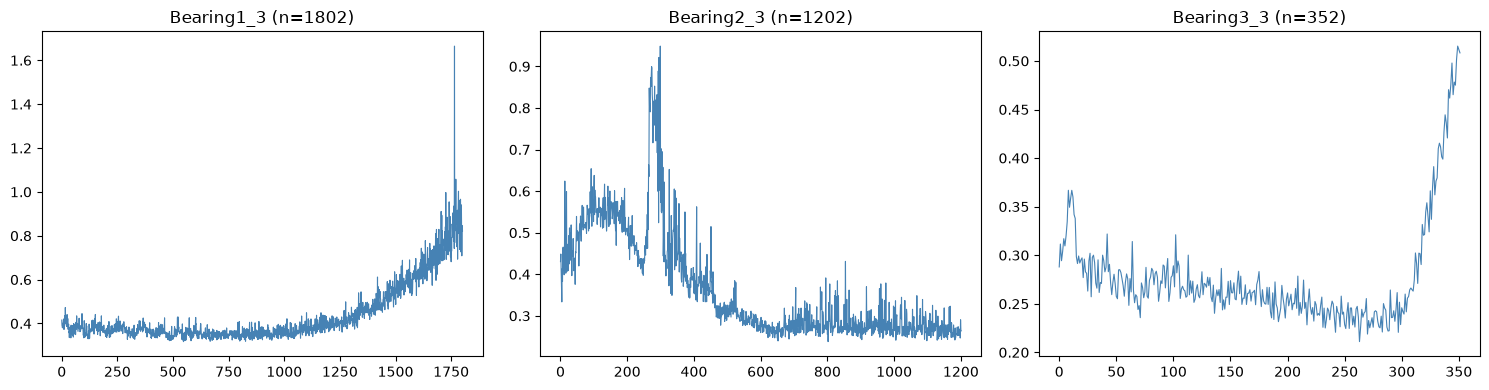

In [14]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame
names = ["Bearing1_3","Bearing2_3","Bearing3_3"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n in zip(axes, names):
    rms = build_feature_frame(config.DATA_ROOT/"Test_set"/n)["h_rms"].to_numpy()
    ax.plot(rms, color="steelblue", lw=0.8); ax.set_title(f"{n} (n={len(rms)})")
plt.tight_layout()

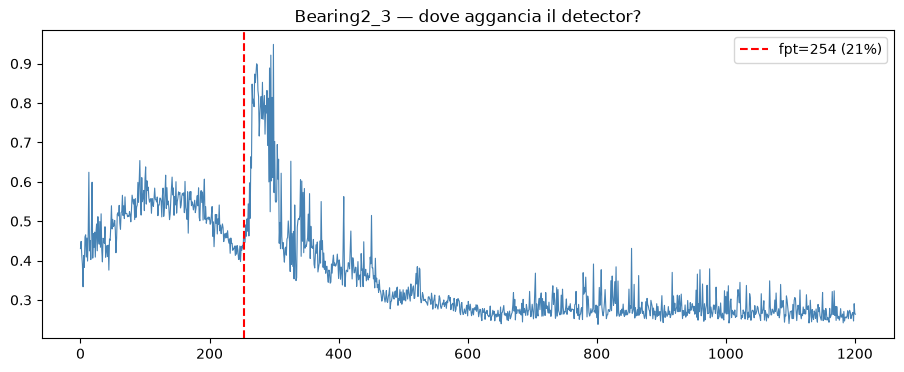

In [15]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame
from src.labeling import detect_fpt_slope

rms = build_feature_frame(config.DATA_ROOT/"Test_set"/"Bearing2_3")["h_rms"].to_numpy()
fpt = detect_fpt_slope(rms)
plt.figure(figsize=(11,4))
plt.plot(rms, color="steelblue", lw=0.8)
plt.axvline(fpt, color="red", ls="--", label=f"fpt={fpt} ({100*fpt/len(rms):.0f}%)")
plt.title("Bearing2_3 — dove aggancia il detector?"); plt.legend()

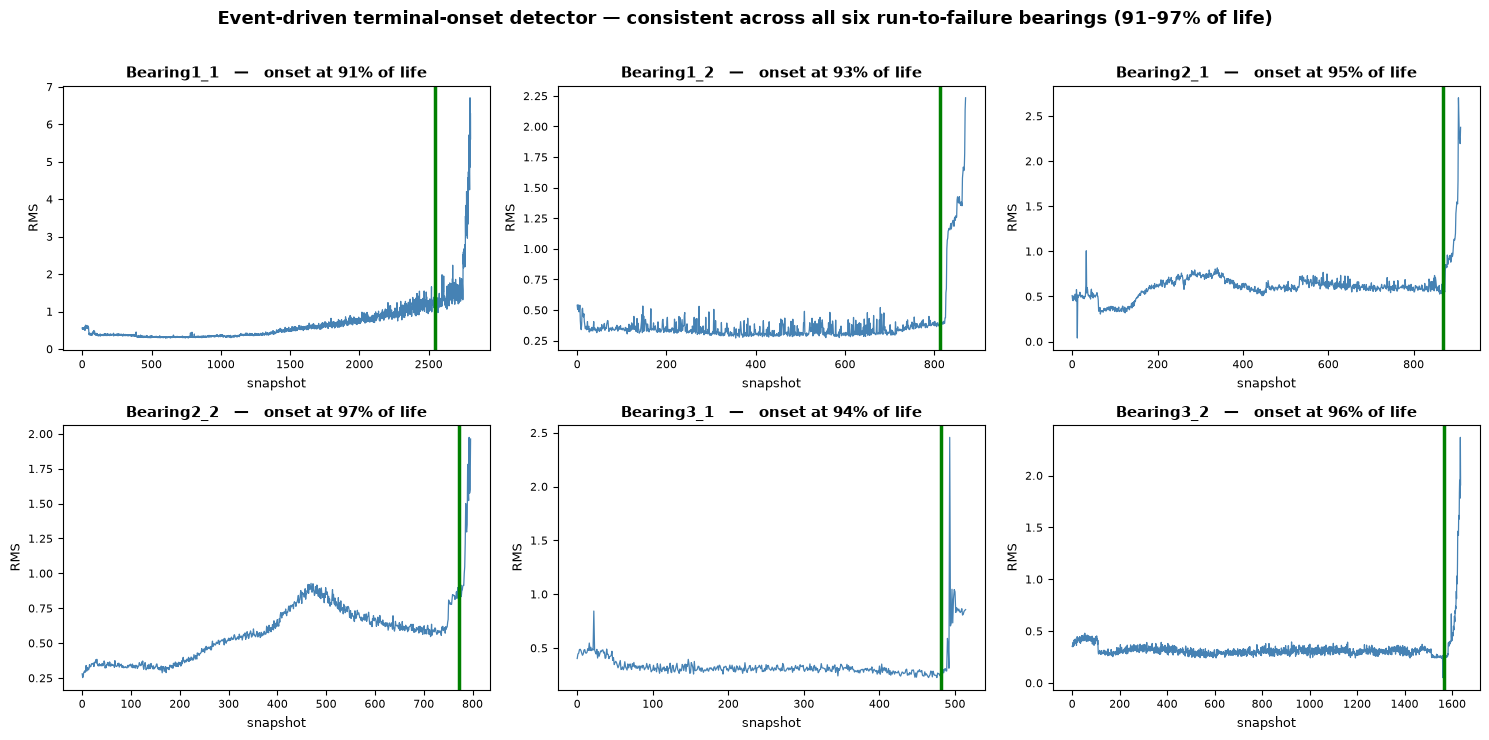

In [16]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame
from src.labeling import detect_fpt_slope

names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1","Bearing3_2"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, n in zip(axes.ravel(), names):
    rms = build_feature_frame(config.DATA_ROOT/"Learning_set"/n)["h_rms"].to_numpy()
    fpt = detect_fpt_slope(rms)
    ax.plot(rms, color="steelblue", lw=0.9)
    ax.axvline(fpt, color="green", lw=2.5)
    ax.set_title(f"{n}   —   onset at {100*fpt/len(rms):.0f}% of life",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("snapshot", fontsize=9); ax.set_ylabel("RMS", fontsize=9)
    ax.tick_params(labelsize=8)
fig.suptitle("Event-driven terminal-onset detector — consistent across all six run-to-failure bearings (91–97% of life)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])

## 7. Is there an early-warning signal? (a negative result)

Could an impulsivity feature (kurtosis, crest/impulse factor, high-band energy) flag incipient degradation *before* the terminal collapse — a 'yellow' alarm? I investigated. The signal exists but is diffuse and not a localisable event, so it does not support a reliable second knee. Reported honestly as a negative result.

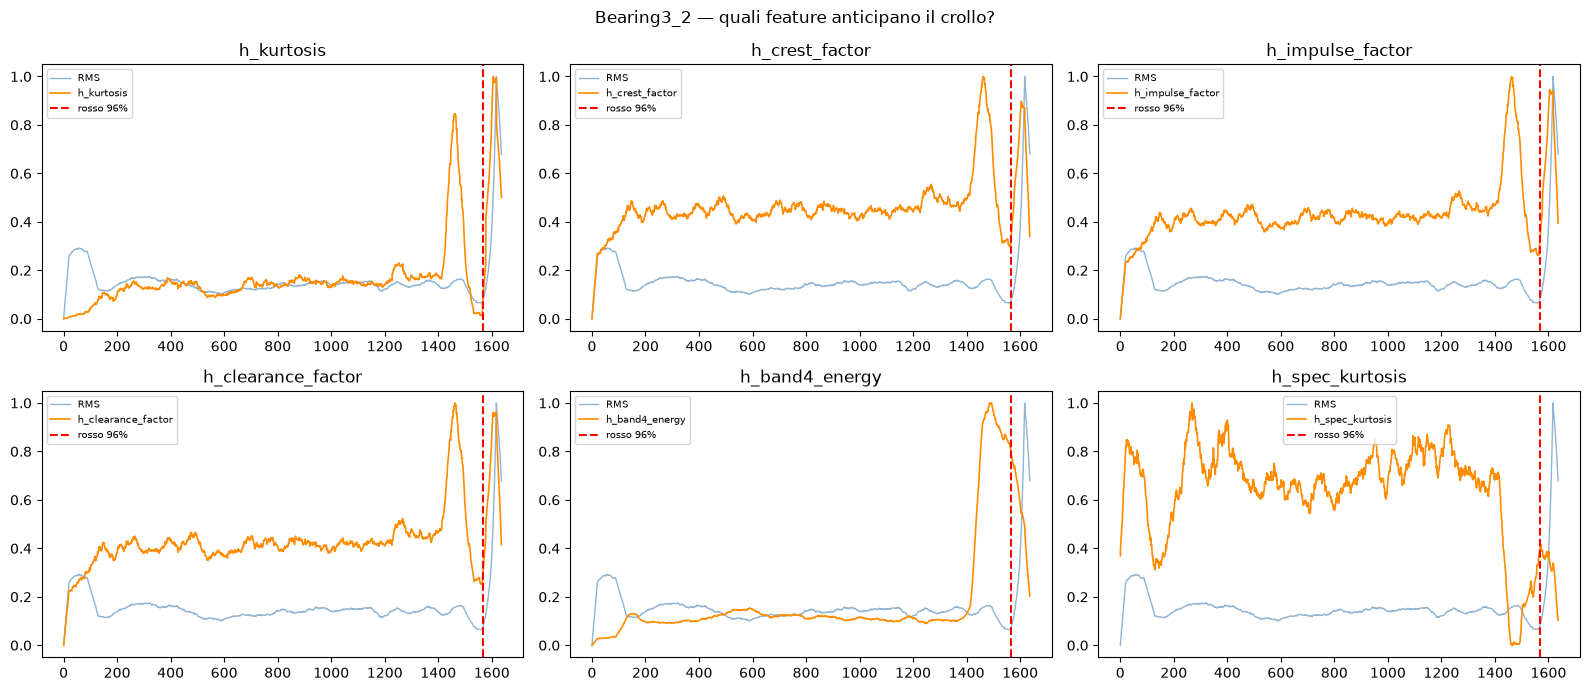

In [17]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame
from src.labeling import detect_fpt_slope

def norm(x):
    x = np.asarray(x, float); return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-9)

n = "Bearing3_2"
df = build_feature_frame(config.DATA_ROOT/"Learning_set"/n)
rms = df["h_rms"].to_numpy()
red = detect_fpt_slope(rms)
win = max(5, len(rms)//40)
def sm(x): return np.convolve(np.asarray(x,float), np.ones(win)/win, mode="same")

feats = ["h_kurtosis","h_crest_factor","h_impulse_factor","h_clearance_factor","h_band4_energy","h_spec_kurtosis"]
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, f in zip(axes.ravel(), feats):
    ax.plot(norm(sm(rms)), color="steelblue", lw=1, alpha=0.6, label="RMS")
    ax.plot(norm(sm(df[f].to_numpy())), color="darkorange", lw=1.2, label=f)
    ax.axvline(red, color="red", ls="--", label=f"rosso {100*red/len(rms):.0f}%")
    ax.set_title(f); ax.legend(fontsize=7)
plt.suptitle(f"{n} — quali feature anticipano il crollo?")
plt.tight_layout()

## 8. Two-stage evaluation: does event-driven labelling help?

The detector raises the alarm; only then is the RUL regression trusted. We evaluate in that post-alarm regime with leave-one-bearing-out over the six run-to-failure bearings. Note the honest caveat that the prediction plots reveal: the nRMSE gain is real but the models do not actually track the terminal ramp. The bottleneck is data observability, not model capacity.

In [18]:
import numpy as np, torch
from xgboost import XGBRegressor
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from torch.utils.data import DataLoader

RUL_SCALE, WINDOW = 1.0/9000.0, 30
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]
val_name = "Bearing3_2"; test_names = ["Bearing1_3","Bearing2_3","Bearing3_3"]
dev = get_device()

def nrmse(yt, yp, life):
    # RMSE normalizzato dalla vita totale del cuscinetto (adimensionale)
    return np.sqrt(np.mean((yt-yp)**2)) / life

def run_mode(MODE):
    tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in train_names}
    scalers, cols = fit_scalers(tr)
    vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, label_mode=MODE, cache=False)}
    test = {n: prepare_bearing(config.DATA_ROOT/"Test_set"/n, label_mode=MODE, cache=False) for n in test_names}
    def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
    Xtr = np.concatenate([apply_scaler(n,df,scalers,cols) for n,(df,_) in tr.items()])
    ytr = np.concatenate([t for _,t in tr.values()])
    xgb = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.03,
                       subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42).fit(Xtr, ytr)
    torch.manual_seed(0); np.random.seed(0)
    m = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
    out = train_model(m, DataLoader(SequenceDataset(pairs(tr),WINDOW),128,shuffle=True),
                      DataLoader(SequenceDataset(pairs(vd),WINDOW),128), epochs=100)
    m = out["model"]; m.eval()
    res = {}
    for n,(df,ytrue) in test.items():
        life = len(ytrue)*10.0
        xp = xgb.predict(apply_scaler(n,df,scalers,cols))
        Xseq,_ = make_sequences(apply_scaler(n,df,scalers,cols), ytrue*RUL_SCALE, window=WINDOW)
        with torch.no_grad():
            lp = m(torch.from_numpy(Xseq).to(dev)).cpu().numpy()/RUL_SCALE
        yl = ytrue[WINDOW-1:]
        d = int(0.85*len(ytrue))          # ultimo 15% = fase di degrado
        dl = int(0.85*len(yl))
        res[n] = {
            "xgb_full": nrmse(ytrue, xp, life), "lstm_full": nrmse(yl, lp, life),
            "xgb_degr": nrmse(ytrue[d:], xp[d:], life), "lstm_degr": nrmse(yl[dl:], lp[dl:], life),
        }
    return res

print(f"{'mode':<16}{'bearing':<11}{'nRMSE full':>22}{'nRMSE degrado':>24}")
print(f"{'':16}{'':11}{'XGB / LSTM':>22}{'XGB / LSTM':>24}")
for MODE in ["linear","capped","piecewise_slope"]:
    r = run_mode(MODE)
    for n in test_names:
        v = r[n]
        print(f"{MODE:<16}{n:<11}{v['xgb_full']:>10.3f} /{v['lstm_full']:>9.3f}"
              f"{v['xgb_degr']:>12.3f} /{v['lstm_degr']:>9.3f}")
    print()

mode            bearing                nRMSE full           nRMSE degrado
                                       XGB / LSTM              XGB / LSTM
epoch   1 | train       0.18 | val       0.10
epoch   2 | train       0.03 | val       0.11
epoch   3 | train       0.02 | val       0.14
epoch   4 | train       0.01 | val       0.13
epoch   5 | train       0.01 | val       0.14
epoch   6 | train       0.01 | val       0.13
epoch   7 | train       0.01 | val       0.15
epoch   8 | train       0.01 | val       0.16
epoch   9 | train       0.01 | val       0.16
epoch  10 | train       0.01 | val       0.17
epoch  11 | train       0.01 | val       0.17
early stopping at epoch 11
linear          Bearing1_3      0.322 /    0.207       0.428 /    0.182
linear          Bearing2_3      0.268 /    0.306       0.461 /    0.455
linear          Bearing3_3      0.439 /    0.465       0.567 /    0.595

epoch   1 | train       0.03 | val       0.00
epoch   2 | train       0.00 | val       0.00
epoch   3 

In [19]:
import numpy as np, torch
from xgboost import XGBRegressor
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from src.labeling import detect_fpt_slope
from torch.utils.data import DataLoader

RUL_SCALE, WINDOW = 1.0/9000.0, 30
all_bearings = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1","Bearing3_2"]
dev = get_device()

def nrmse(yt, yp, life): return np.sqrt(np.mean((yt-yp)**2)) / life

def loo_eval(MODE):
    rows = []
    for held in all_bearings:
        train_n = [b for b in all_bearings if b != held]
        # dei 5 di training, l'ultimo fa da validation per l'early stopping
        fit_n, val_n = train_n[:-1], train_n[-1]
        tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in fit_n}
        scalers, cols = fit_scalers(tr)
        vd = {val_n: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_n, label_mode=MODE, cache=False)}
        def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
        # XGB
        Xtr = np.concatenate([apply_scaler(n,df,scalers,cols) for n,(df,_) in tr.items()])
        ytr = np.concatenate([t for _,t in tr.values()])
        xgb = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.03,
                           subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42).fit(Xtr, ytr)
        # LSTM
        torch.manual_seed(0); np.random.seed(0)
        m = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
        out = train_model(m, DataLoader(SequenceDataset(pairs(tr),WINDOW),128,shuffle=True),
                          DataLoader(SequenceDataset(pairs(vd),WINDOW),128), epochs=100)
        m = out["model"]; m.eval()
        # valutazione sul cuscinetto tenuto fuori, regime post-allarme
        df, ytrue = prepare_bearing(config.DATA_ROOT/"Learning_set"/held, label_mode=MODE, cache=False)
        life = len(ytrue)*10.0
        fpt = detect_fpt_slope(df["h_rms"].to_numpy())
        xp = xgb.predict(apply_scaler(held,df,scalers,cols))
        Xseq,_ = make_sequences(apply_scaler(held,df,scalers,cols), ytrue*RUL_SCALE, window=WINDOW)
        with torch.no_grad():
            lp = m(torch.from_numpy(Xseq).to(dev)).cpu().numpy()/RUL_SCALE
        yl = ytrue[WINDOW-1:]
        mx = np.arange(len(ytrue)) >= fpt
        ml = np.arange(WINDOW-1, WINDOW-1+len(lp)) >= fpt
        rows.append((held, 100*fpt/len(ytrue),
                     nrmse(ytrue[mx],xp[mx],life), nrmse(yl[ml],lp[ml],life)))
    return rows

for MODE in ["capped","piecewise_slope"]:
    print(f"\n=== {MODE} — leave-one-out, regime post-allarme (nRMSE) ===")
    print(f"{'held-out':<12}{'fpt%':>6}{'XGB':>9}{'LSTM':>9}")
    xs, ls = [], []
    for held, fp, xr, lr in loo_eval(MODE):
        print(f"{held:<12}{fp:>5.0f}%{xr:>9.3f}{lr:>9.3f}")
        xs.append(xr); ls.append(lr)
    print(f"{'MEDIA':<12}{'':>6}{np.mean(xs):>9.3f}{np.mean(ls):>9.3f}")


=== capped — leave-one-out, regime post-allarme (nRMSE) ===
held-out      fpt%      XGB     LSTM
epoch   1 | train       0.05 | val       0.00
epoch   2 | train       0.01 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.01
epoch   7 | train       0.00 | val       0.01
epoch   8 | train       0.00 | val       0.01
epoch   9 | train       0.00 | val       0.01
epoch  10 | train       0.00 | val       0.01
epoch  11 | train       0.00 | val       0.00
epoch  12 | train       0.00 | val       0.01
early stopping at epoch 12
epoch   1 | train       0.03 | val       0.00
epoch   2 | train       0.00 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.00
epoch   7 | train       0.00 | val       0.00
e

epoch   1 | train       0.05 | val       0.00
epoch   2 | train       0.01 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.01
epoch   7 | train       0.00 | val       0.01
epoch   8 | train       0.00 | val       0.01
epoch   9 | train       0.00 | val       0.01
epoch  10 | train       0.00 | val       0.01
epoch  11 | train       0.00 | val       0.00
epoch  12 | train       0.00 | val       0.01
early stopping at epoch 12
epoch   1 | train       0.12 | val       0.01
epoch   2 | train       0.00 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.00
epoch   7 | train       0.00 | val       0.00
epoch   8 | train       0.00 | val       0.00
epoch   9 | train       0.00 | val       0.00
epoch  

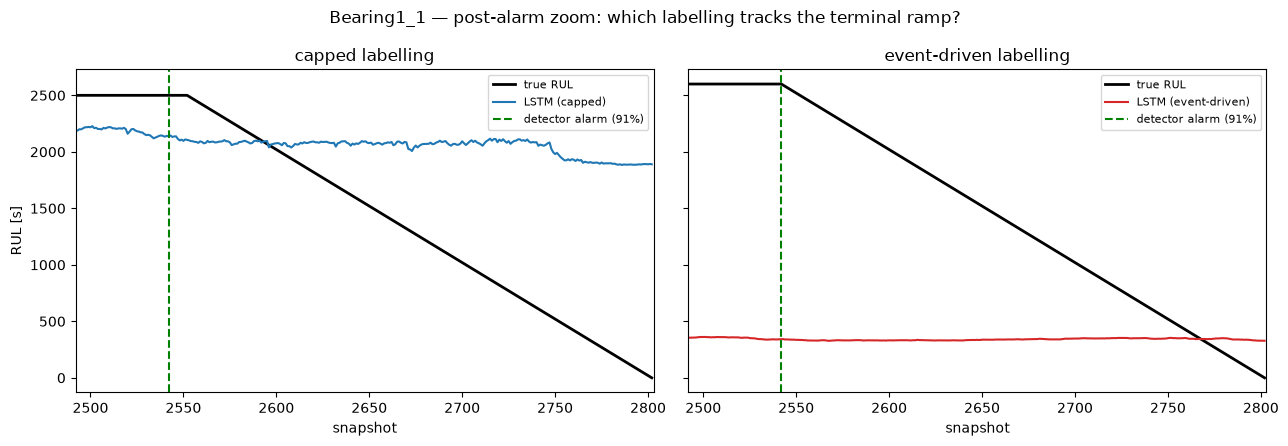

In [20]:
import numpy as np, matplotlib.pyplot as plt, torch
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from src.labeling import detect_fpt_slope
from torch.utils.data import DataLoader

RUL_SCALE, WINDOW = 1.0/9000.0, 30
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]
val_name = "Bearing3_2"; show = "Bearing1_1"
dev = get_device()

def train_predict(MODE, held):
    fit_n = [b for b in train_names if b != held]
    tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in fit_n}
    scalers, cols = fit_scalers(tr)
    vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, label_mode=MODE, cache=False)}
    def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
    torch.manual_seed(0); np.random.seed(0)
    m = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
    out = train_model(m, DataLoader(SequenceDataset(pairs(tr),WINDOW),128,shuffle=True),
                      DataLoader(SequenceDataset(pairs(vd),WINDOW),128), epochs=100)
    m = out["model"]; m.eval()
    df, ytrue = prepare_bearing(config.DATA_ROOT/"Learning_set"/held, label_mode=MODE, cache=False)
    Xseq,_ = make_sequences(apply_scaler(held,df,scalers,cols), ytrue*RUL_SCALE, window=WINDOW)
    with torch.no_grad():
        lp = m(torch.from_numpy(Xseq).to(dev)).cpu().numpy()/RUL_SCALE
    return ytrue, lp

yc, pc = train_predict("capped", show)
ys, ps = train_predict("piecewise_slope", show)
rms = prepare_bearing(config.DATA_ROOT/"Learning_set"/show, label_mode="capped", cache=False)[0]["h_rms"].to_numpy()
fpt = detect_fpt_slope(rms)
z = fpt - 50   # zoom: da poco prima dell'allarme fino alla fine

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
xc = np.arange(WINDOW-1, WINDOW-1+len(pc))
xs = np.arange(WINDOW-1, WINDOW-1+len(ps))
ax[0].plot(range(len(yc)), yc, "k", lw=2, label="true RUL")
ax[0].plot(xc, pc, color="tab:blue", lw=1.5, label="LSTM (capped)")
ax[1].plot(range(len(ys)), ys, "k", lw=2, label="true RUL")
ax[1].plot(xs, ps, color="tab:red", lw=1.5, label="LSTM (event-driven)")
for a,t in zip(ax, ["capped labelling","event-driven labelling"]):
    a.axvline(fpt, color="green", ls="--", lw=1.5, label=f"detector alarm ({100*fpt/len(yc):.0f}%)")
    a.set_xlim(z, len(yc)); a.set_title(t); a.set_xlabel("snapshot"); a.legend(fontsize=8)
ax[0].set_ylabel("RUL [s]")
fig.suptitle(f"{show} — post-alarm zoom: which labelling tracks the terminal ramp?")
plt.tight_layout()